In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8.zip' -d '/content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8'

Streaming output truncated to the last 5000 lines.
 extracting: /content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8/train/labels/vid_000158_frame0000030_jpg.rf.bc20eabf4eb8be532242077b13a95db2.txt  
 extracting: /content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8/train/labels/vid_000158_frame0000032_jpg.rf.578c961c7acd7a1134c05ba36c93e2d1.txt  
 extracting: /content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8/train/labels/vid_000158_frame0000033_jpg.rf.7f7815efbfe7ea0e7e53d93f8e7abde7.txt  
 extracting: /content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8/train/labels/vid_000158_frame0000034_jpg.rf.8df8b55c9bcaac5157b094574df345e9.txt  
 extracting: /content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8/train/labels/vid_000158_frame0000035_jpg.rf.20804bace695b47713fb95b08d703e37.txt  
 extracting: /content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset

In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd

In [6]:
dataset_path = '/content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8/train'
image_path = os.path.join(dataset_path, 'images')
label_path = os.path.join(dataset_path, 'labels')

# Get list of image files
image_files = [os.path.join(image_path, file) for file in os.listdir(image_path) if file.endswith('.jpg')]
class_names = ['animal_crab', 'animal_eel', 'animal_etc', 'animal_fish', 'animal_shells', 'animal_starfish', 'plant', 'rov', 'trash_bag', 'trash_bottle', 'trash_branch', 'trash_can', 'trash_clothing', 'trash_container', 'trash_cup', 'trash_net', 'trash_pipe', 'trash_rope', 'trash_snack_wrapper', 'trash_tarp', 'trash_unknown_instance', 'trash_wreckage']

class_dict_names = {i: name for i, name in enumerate(class_names)}
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]  # Different colors for each class
colors_normalized = [(r / 255, g / 255, b / 255) for (r, g, b) in colors]

In [7]:
class_dict_names

{0: 'animal_crab',
 1: 'animal_eel',
 2: 'animal_etc',
 3: 'animal_fish',
 4: 'animal_shells',
 5: 'animal_starfish',
 6: 'plant',
 7: 'rov',
 8: 'trash_bag',
 9: 'trash_bottle',
 10: 'trash_branch',
 11: 'trash_can',
 12: 'trash_clothing',
 13: 'trash_container',
 14: 'trash_cup',
 15: 'trash_net',
 16: 'trash_pipe',
 17: 'trash_rope',
 18: 'trash_snack_wrapper',
 19: 'trash_tarp',
 20: 'trash_unknown_instance',
 21: 'trash_wreckage'}

Number of training images: 4993
Number of validation images: 1425
Number of test images: 714


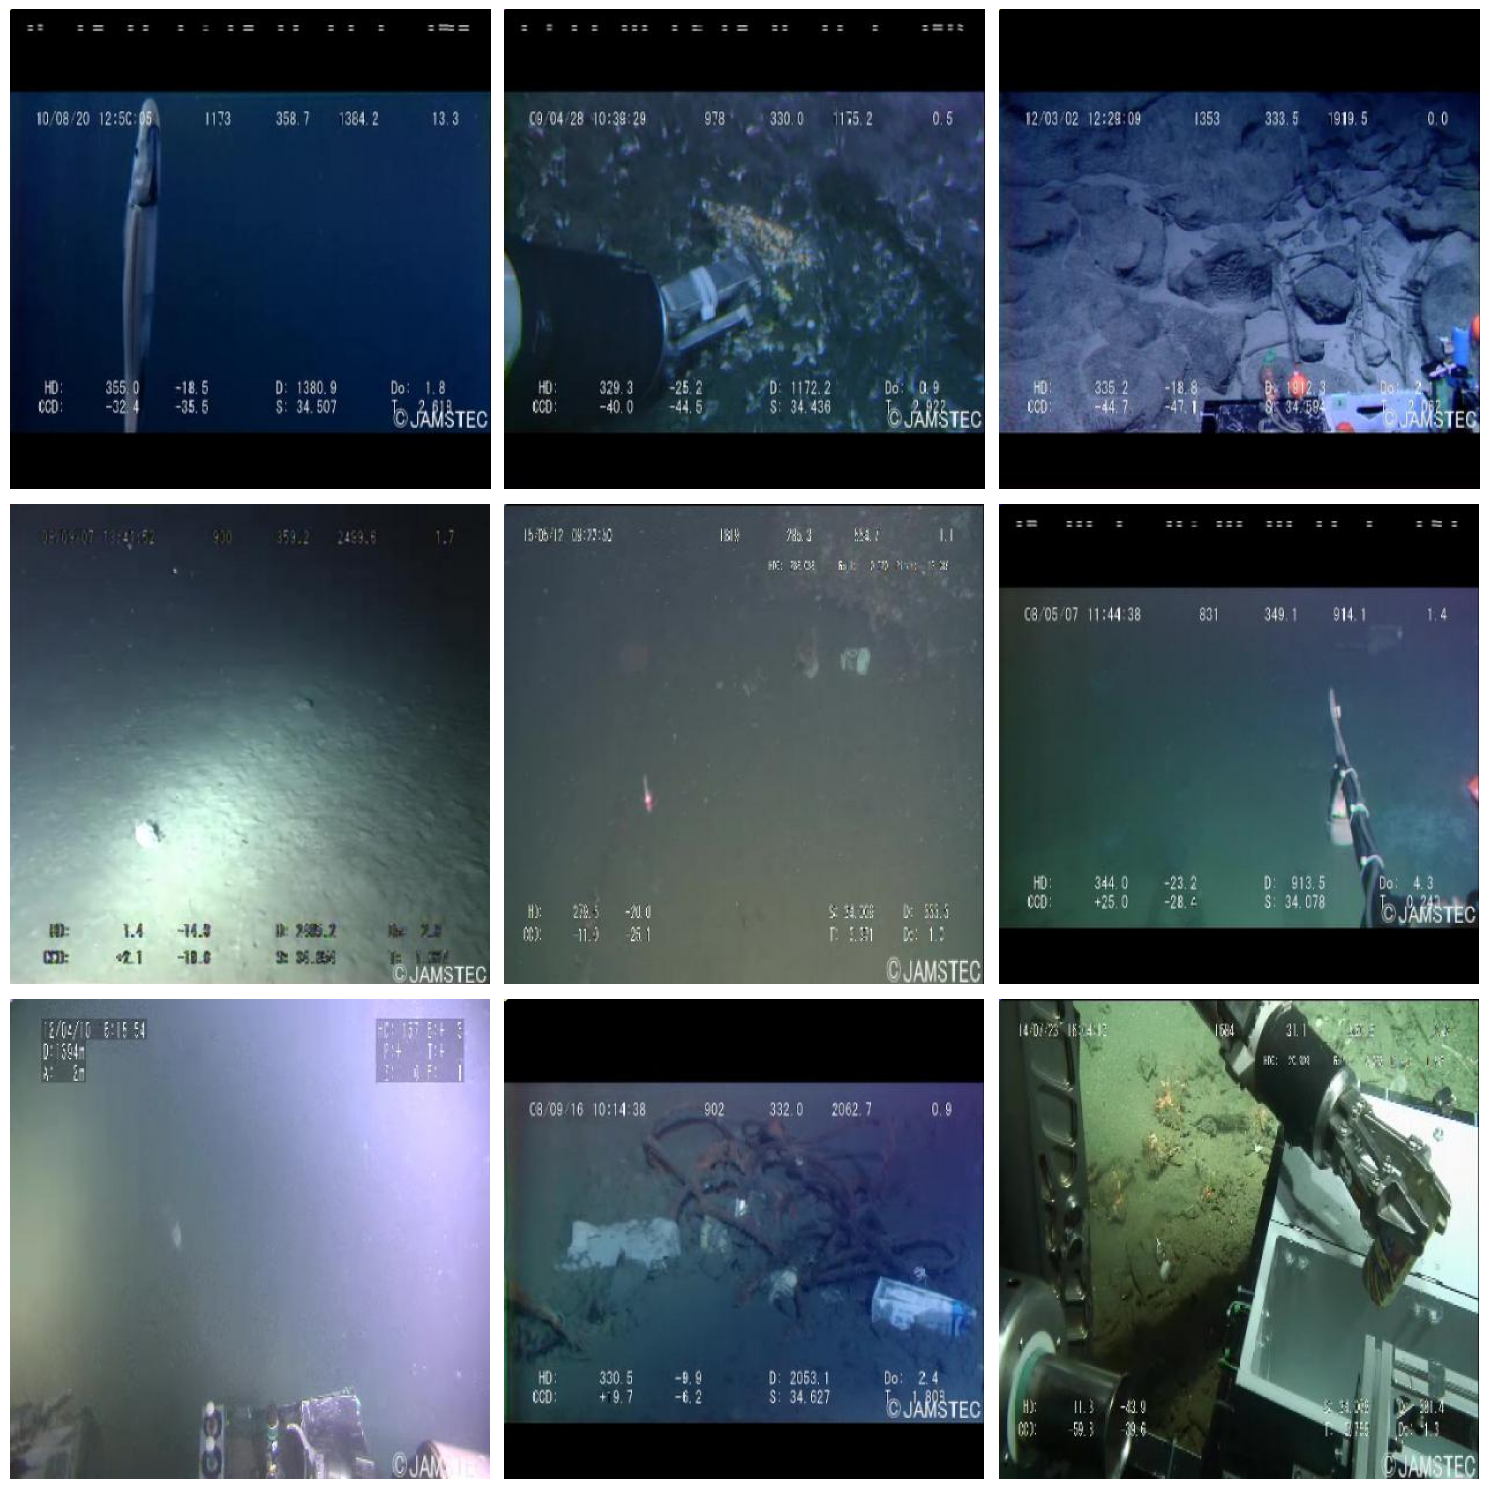

Total images per class: {12: 59, 1: 246, 20: 1926, 19: 85, 10: 221, 7: 2379, 18: 61, 5: 294, 13: 350, 3: 559, 8: 628, 21: 116, 0: 195, 6: 356, 15: 83, 17: 86, 2: 154, 4: 174, 11: 323, 14: 32, 9: 89, 16: 100}


In [8]:
import os
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np

# Define paths
base_path = '/content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8'
train_images_path = os.path.join(base_path, 'train', 'images')
train_labels_path = os.path.join(base_path, 'train', 'labels')
val_images_path = os.path.join(base_path, 'valid', 'images')
test_images_path = os.path.join(base_path, 'test', 'images')

# Function to count files
def count_files(directory):
    return len([name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name))])

# Displaying counts for train, val, and test directories
train_count = count_files(train_images_path)
val_count = count_files(val_images_path)
test_count = count_files(test_images_path)
print("Number of training images:", train_count)
print("Number of validation images:", val_count)
print("Number of test images:", test_count)

# Function to display images with segmented colors and labels
def display_segmented_images(image_folder, label_folder, num_images=9):
    image_files = [os.path.join(image_folder, file) for file in os.listdir(image_folder) if file.endswith('.jpg')]
    sampled_images = random.sample(image_files, min(len(image_files), num_images))

    fig, axs = plt.subplots(3, 3, figsize=(15, 15))
    axs = axs.flatten()

    for ax, img_path in zip(axs, sampled_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        label_file = os.path.join(label_folder, os.path.basename(img_path).replace('.jpg', '.txt'))
        with open(label_file, 'r') as file:
            data = file.readlines()
            for line in data:
                elements = line.split()
                class_id = int(elements[0])
                coordinates = list(map(float, elements[1:]))
                polygon = np.array([[(x, y) for x, y in zip(coordinates[0::2], coordinates[1::2])]], dtype=np.int32)
                cv2.polylines(img, [polygon], isClosed=True, color=np.random.randint(0, 255, size=3).tolist(), thickness=2)

        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display images
display_segmented_images(train_images_path, train_labels_path)

# Function to calculate total images for each class across all datasets
def total_images_for_each_class(image_folder, label_folder):
    class_counts = {}
    label_files = [os.path.join(label_folder, file) for file in os.listdir(label_folder) if file.endswith('.txt')]
    for label_file in label_files:
        with open(label_file, 'r') as file:
            data = file.readlines()
            for line in data:
                class_id = int(line.split()[0])
                class_counts[class_id] = class_counts.get(class_id, 0) + 1
    return class_counts

# Calculate and display the total number of images for each class
class_counts = total_images_for_each_class(train_images_path, train_labels_path)
print("Total images per class:", class_counts)


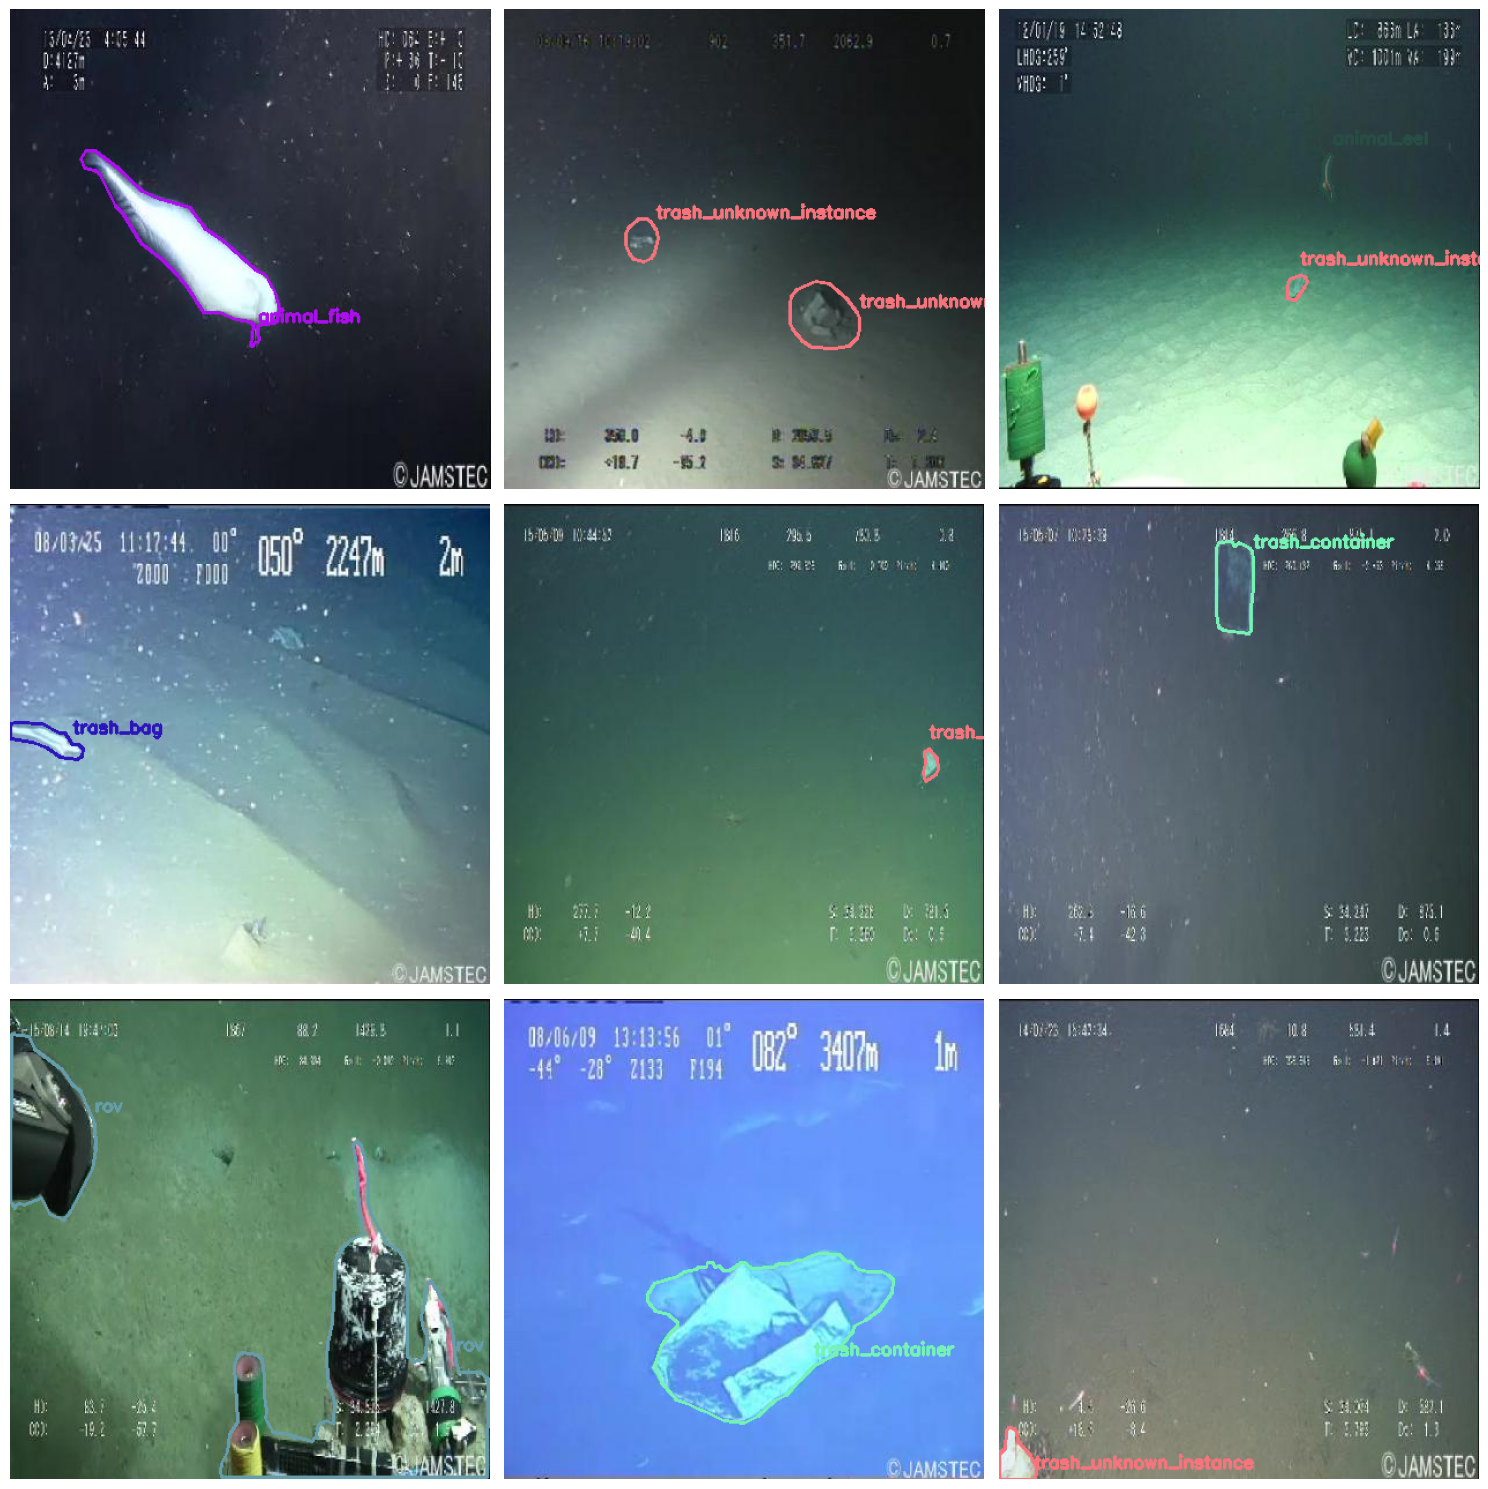

In [9]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np

# Define paths
base_path = '/content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8'
train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'valid')
test_path = os.path.join(base_path, 'test')

image_path = os.path.join(train_path, 'images')
label_path = os.path.join(train_path, 'labels')

# Get list of image files
image_files = [os.path.join(image_path, file) for file in os.listdir(image_path) if file.endswith('.jpg')]

# Define class names and generate colors
class_names = ['animal_crab', 'animal_eel', 'animal_etc', 'animal_fish', 'animal_shells', 'animal_starfish', 'plant', 'rov', 'trash_bag', 'trash_bottle', 'trash_branch', 'trash_can', 'trash_clothing', 'trash_container', 'trash_cup', 'trash_net', 'trash_pipe', 'trash_rope', 'trash_snack_wrapper', 'trash_tarp', 'trash_unknown_instance', 'trash_wreckage']
colors = [tuple(int(x * 255) for x in np.random.rand(3)) for _ in range(len(class_names))]  # Generate random colors for each class

def display_images(image_files, num_images=9):
    selected_images = random.sample(image_files, min(num_images, len(image_files)))

    fig, axs = plt.subplots(3, 3, figsize=(15, 15))
    for i, img_path in enumerate(selected_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        txt_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
        with open(txt_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])
                vertices = np.array([float(x) for x in parts[1:]]).reshape((-1, 2))
                vertices[:, 0] *= img.shape[1]
                vertices[:, 1] *= img.shape[0]
                vertices = vertices.astype(np.int32)
                cv2.polylines(img, [vertices], isClosed=True, color=colors[class_id], thickness=2)
                cv2.putText(img, class_names[class_id], (vertices[0][0], vertices[0][1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[class_id], 2)

        ax = axs[i // 3, i % 3]
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('3.png')
    plt.show()

display_images(image_files)


In [10]:
def count_images(directory):
    return len([name for name in os.listdir(os.path.join(directory, 'images')) if name.endswith('.jpg')])

train_count = count_images(train_path)
val_count = count_images(val_path)
test_count = count_images(test_path)
print("********** Trash Dataset of 22 classes ***************")
print(f"Number of images in Train: {train_count}")
print(f"Number of images in Validation: {val_count}")
print(f"Number of images in Test: {test_count}")


********** Trash Dataset of 22 classes ***************
Number of images in Train: 4993
Number of images in Validation: 1425
Number of images in Test: 714


In [11]:
from collections import defaultdict

def count_classes_across_datasets(base_path, class_names):
    counts = defaultdict(int)
    for phase in ['train', 'valid', 'test']:
        label_dir = os.path.join(base_path, phase, 'labels')
        for label_file in os.listdir(label_dir):
            with open(os.path.join(label_dir, label_file), 'r') as f:
                for line in f:
                    class_id = int(line.strip().split()[0])
                    counts[class_names[class_id]] += 1
    return dict(counts)

class_counts = count_classes_across_datasets(base_path, class_names)
print("Image count per class across all datasets:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")


Image count per class across all datasets:
trash_clothing: 82
animal_eel: 336
trash_unknown_instance: 2735
trash_tarp: 121
trash_branch: 329
rov: 3420
trash_snack_wrapper: 84
animal_starfish: 397
trash_container: 506
animal_fish: 759
trash_bag: 879
trash_wreckage: 164
animal_crab: 304
plant: 502
trash_net: 127
trash_rope: 109
animal_etc: 234
animal_shells: 247
trash_can: 455
trash_cup: 59
trash_bottle: 126
trash_pipe: 142


<ipython-input-12-ed6bde4f463a>:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('hsv', len(class_names))


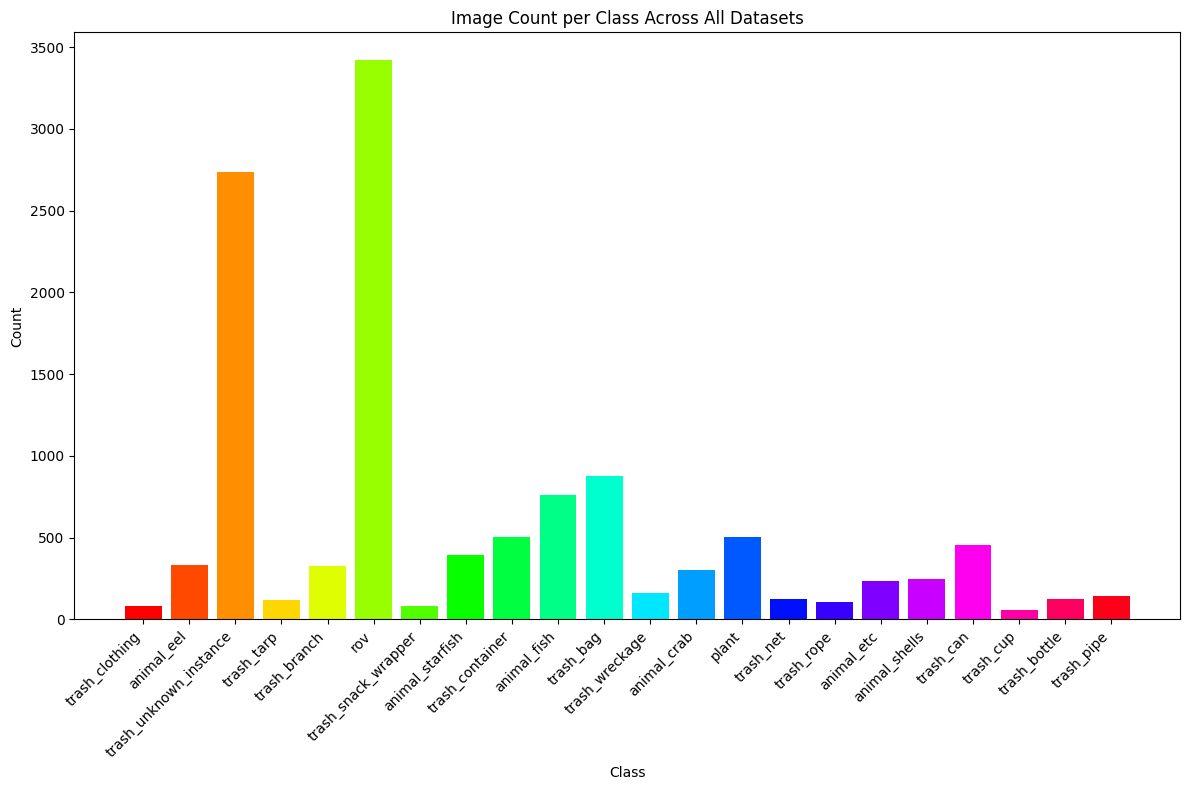

In [12]:
colors = plt.cm.get_cmap('hsv', len(class_names))

# Create the bar plot
plt.figure(figsize=(12, 8))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=[colors(i) for i in range(len(class_counts))])

# Add labels and title
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Image Count per Class Across All Datasets')
plt.xticks(rotation=45, ha='right')  # Rotate class names for better readability

# Show the plot
plt.tight_layout()
plt.savefig('trash_can_dataset_dist_22.png')
plt.show()

In [2]:
!pip install ultralytics==8.0.28

from IPython import display
display.clear_output()


import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.28 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 33.6/78.2 GB disk)


In [4]:
!yolo segment train model=yolov8s-seg.pt data=/content/drive/MyDrive/UnderWater\ Trash\ Detection/Trashcan\ Dataset.v3i.yolov8/data.yaml epochs=10 imgsz=640 save=true batch=8


100% 22.8M/22.8M [00:00<00:00, 243MB/s]
Ultralytics YOLOv8.0.28 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
yolo/engine/trainer: task=segment, mode=train, model=yolov8s-seg.pt, data=/content/drive/MyDrive/UnderWater Trash Detection/Trashcan Dataset.v3i.yolov8/data.yaml, epochs=10, patience=50, batch=8, imgsz=640, save=True, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=False, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, image_weights=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, hide_labels=False, hide_conf=False, vid_stride=1, line_thickness=3, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, forma

In [5]:
!zip -r /content/drive/MyDrive/UnderWater\ Trash\ Detection/trashcan-yolov8.zip /content/runs


  adding: content/runs/ (stored 0%)
  adding: content/runs/segment/ (stored 0%)
  adding: content/runs/segment/train/ (stored 0%)
  adding: content/runs/segment/train/BoxR_curve.png (deflated 7%)
  adding: content/runs/segment/train/events.out.tfevents.1724024754.12da7d9ddb72.1402.0 (deflated 72%)
  adding: content/runs/segment/train/train_batch1.jpg (deflated 17%)
  adding: content/runs/segment/train/train_batch2.jpg (deflated 19%)
  adding: content/runs/segment/train/BoxP_curve.png (deflated 7%)
  adding: content/runs/segment/train/MaskF1_curve.png (deflated 6%)
  adding: content/runs/segment/train/results.csv (deflated 82%)
  adding: content/runs/segment/train/train_batch0.jpg (deflated 24%)
  adding: content/runs/segment/train/MaskPR_curve.png (deflated 6%)
  adding: content/runs/segment/train/MaskP_curve.png (deflated 7%)
  adding: content/runs/segment/train/weights/ (stored 0%)
  adding: content/runs/segment/train/weights/last.pt (deflated 8%)
  adding: content/runs/segment/train